# Kế Hoạch Thực Tập: AI Y Tế Đa Phương Thức (9 Notebooks Pipeline)
## Notebook 5: Siêu mô hình TransMIL (SOTA Deep Learning - Official Architecture)

**Sự trỗi dậy của Mạng Nơ-ron Chú ý (Attention) và Không gian 2D:**
Sau thất bại thảm hại của cả Machine Learning Truyền thống (Notebook 3) và Neural Network Tiêu chuẩn (Notebook 4), chúng ta đã chứng minh được: **Kỹ thuật ép dẹp trung bình (Mean-Pooling) là kẻ thù số một của dữ liệu Y tế WSI.**

Trong Notebook này, chúng ta sẽ triển khai nguyên bản kiến trúc **TransMIL (Shao et al., NeurIPS 2021)** - kiến trúc State-of-the-Art (SOTA) mạnh nhất hiện nay trong phân tích bệnh học kỹ thuật số. So với bản Hybrid tự build, bản gốc này sở hữu 3 vũ khí hủy diệt:

1. **Nyströmformer ($O(n)$):** Thay vì Standard Transformer bị quá tải với 5000 mảnh tế bào, thuật toán xấp xỉ Nyström giúp mô hình học mượt mà hàng vạn mảnh tế bào cùng lúc mà không bị tràn RAM.
2. **PPEG (Pyramid Position Encoding Generator):** Module CNN độc quyền giúp tái tạo lại tọa độ không gian 2D cho các tế bào. Mạng AI sẽ nhận thức được tế bào số 1 và số 2 đang nằm cạnh nhau, giúp nó phát hiện khối u mọc thành cụm.
3. **[CLS] Token Aggregation:** Nó không dùng hàm `Tanh` lỗi thời, mà tung vào chuỗi tế bào một biến gián điệp `[CLS]`. Biến này đi qua toàn bộ mạng, liên tục nghe ngóng và thu thập tín hiệu ung thư HER2 từ các mảnh tế bào khác, cuối cùng gom lại thành 1 siêu vector chứa toàn thông tin tử huyệt.

In [1]:
# Cài đặt thư viện Nyströmformer bắt buộc cho TransMIL
!pip install nystrom-attention

In [2]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from nystrom_attention import NystromAttention

import warnings
warnings.filterwarnings('ignore')

### 1. Chuẩn Bị Dữ Liệu: Bag of Features
DataLoader không gộp trung bình mà load nguyên khối ma trận `[N, 2048]` của từng bệnh nhân.

In [3]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

df = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df.columns) < 5:
    df = pd.read_csv(CLINICAL_CSV)

valid_subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2']
df_filtered = df[df['pam50_subtype'].isin(valid_subtypes)].copy()
label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_filtered['label'] = df_filtered['pam50_subtype'].map(label_map)
patient_label_dict = dict(zip(df_filtered['patientId'], df_filtered['label']))

class MILBagDataset(Dataset):
    def __init__(self, patient_ids, pt_dir, label_dict):
        self.patient_ids = patient_ids
        self.pt_dir = pt_dir
        self.label_dict = label_dict
        
    def __len__(self):
        return len(self.patient_ids)
        
    def __getitem__(self, idx):
        pid = self.patient_ids[idx]
        pt_path = os.path.join(self.pt_dir, f"{pid}.pt")
        features = torch.load(pt_path, map_location='cpu') # Shape: [N, 2048]
        label = self.label_dict[pid]
        return features, label, pid

if os.path.exists(PT_DIR):
    valid_pids = [p for p in df_filtered['patientId'].tolist() if os.path.exists(os.path.join(PT_DIR, f"{p}.pt"))]
    labels = [patient_label_dict[pid] for pid in valid_pids]
    print(f"Tìm thấy {len(valid_pids)} bệnh nhân hợp lệ.")
else:
    print("Lỗi: Không tìm thấy thư mục PT_DIR.")
    valid_pids, labels = [], []

Tìm thấy 882 bệnh nhân hợp lệ.


### 2. Thiết Kế Kiến Trúc TransMIL Gốc (Original Official Architecture)
Mã nguồn được tham khảo chuẩn hóa từ bài báo gốc NeurIPS 2021.

In [4]:
class TransLayer(nn.Module):
    def __init__(self, norm_layer=nn.LayerNorm, dim=512):
        super().__init__()
        self.norm = norm_layer(dim)
        self.attn = NystromAttention(
            dim = dim,
            dim_head = dim//8,
            heads = 8,
            num_landmarks = dim//2,    
            pinv_iterations = 6,    
            residual = True,         
            dropout=0.1
        )

    def forward(self, x):
        x = x + self.attn(self.norm(x))
        return x

class PPEG(nn.Module):
    """
    Pyramid Position Encoding Generator (PPEG)
    Dùng mạng CNN 2D (Conv2d 3, 5, 7) để tái tạo bản đồ tọa độ tế bào giả lập.
    """
    def __init__(self, dim=512):
        super(PPEG, self).__init__()
        self.proj = nn.Conv2d(dim, dim, 7, 1, 7//2, groups=dim)
        self.proj1 = nn.Conv2d(dim, dim, 5, 1, 5//2, groups=dim)
        self.proj2 = nn.Conv2d(dim, dim, 3, 1, 3//2, groups=dim)

    def forward(self, x, H, W):
        B, _, C = x.shape
        cls_token, feat_token = x[:, 0], x[:, 1:]
        cnn_feat = feat_token.transpose(1, 2).view(B, C, H, W)
        x = self.proj(cnn_feat) + cnn_feat + self.proj1(cnn_feat) + self.proj2(cnn_feat)
        x = x.flatten(2).transpose(1, 2)
        x = torch.cat((cls_token.unsqueeze(1), x), dim=1)
        return x

class TransMIL(nn.Module):
    def __init__(self, input_dim=2048, n_classes=4):
        super(TransMIL, self).__init__()
        self.pos_layer = PPEG(dim=512)
        # Nén từ 2048 chiều (ResNet50) xuống 512 chiều
        self._fc1 = nn.Sequential(nn.Linear(input_dim, 512), nn.ReLU())
        self.cls_token = nn.Parameter(torch.randn(1, 1, 512))
        self.n_classes = n_classes
        self.layer1 = TransLayer(dim=512)
        self.layer2 = TransLayer(dim=512)
        self.norm = nn.LayerNorm(512)
        self._fc2 = nn.Linear(512, self.n_classes)

    def forward(self, x):
        # x có shape: [1, N, 2048]
        h = x.float()
        h = self._fc1(h) # [1, N, 512]
        
        # ----> Pad sequence thành hình vuông để dùng CNN 2D cho vị trí (PPEG)
        H = h.shape[1]
        _H, _W = int(np.ceil(np.sqrt(H))), int(np.ceil(np.sqrt(H)))
        add_length = _H * _W - H
        h = torch.cat([h, h[:,:add_length,:]], dim = 1) # [1, _H*_W, 512]

        # ----> Thêm gián điệp [CLS] Token
        B = h.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1) # B=1
        h = torch.cat((cls_tokens, h), dim=1) # [1, _H*_W + 1, 512]

        # ----> Nyström Attention Layer 1
        h = self.layer1(h) 

        # ----> Bơm thông tin tọa độ không gian 2D bằng PPEG
        h = self.pos_layer(h, _H, _W) 
        
        # ----> Nyström Attention Layer 2
        h = self.layer2(h) 

        # ----> Gom kết quả: Chỉ rút thẻ [CLS] ra để chốt phân loại
        h = self.norm(h)[:,0]

        # ----> Phân loại cuối cùng
        logits = self._fc2(h) # [1, 4]
        return logits, None # TransMIL nguyên bản không xuất ma trận A rõ ràng như ABMIL, nên trả về None

### 3. Huấn Luyện SOTA (Stratified 5-Fold)

In [5]:
if len(valid_pids) > 0:
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    
    # [NÂNG CẤP 1] Thêm Label Smoothing 0.1 để chống Overconfidence
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    epochs = 20
    batch_size = 1 # Bắt buộc vì WSI có độ dài biến thiên
    # [NÂNG CẤP 2] Gradient Accumulation giả lập Batch Size 16
    accumulation_steps = 16 
    
    fold_results = []
    best_global_preds = []
    best_global_labels = []

    print(f"Khởi động lò nung SOTA TransMIL (Official + Optimized) trên thiết bị: {device}")
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(valid_pids, labels)):
        print(f"\n--- [TransMIL Official] Bắt đầu Fold {fold + 1}/5 ---")
        
        train_pids = [valid_pids[i] for i in train_idx]
        test_pids = [valid_pids[i] for i in test_idx]
        
        train_dataset = MILBagDataset(train_pids, PT_DIR, patient_label_dict)
        test_dataset = MILBagDataset(test_pids, PT_DIR, patient_label_dict)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        model = TransMIL(input_dim=2048, n_classes=4).to(device)
        # Tăng Learning Rate lên một chút vì đã có Gradient Accumulation
        optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
        # [NÂNG CẤP 3] Cosine Annealing để tốc độ học lượn sóng mượt mà
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        
        best_f1 = 0.0
        best_acc = 0.0
        fold_preds = []
        fold_labels = []
        
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad() # Xóa gradient đầu epoch
            
            for step, (features, label, _) in enumerate(train_loader):
                features, label = features.to(device), label.to(device)
                
                logits, _ = model(features)
                loss = criterion(logits, label)
                # Chia loss cho accumulation_steps để chuẩn hóa gradient
                loss = loss / accumulation_steps 
                loss.backward()
                
                # Chỉ cập nhật tạ khi tích lũy đủ 16 bước
                if (step + 1) % accumulation_steps == 0 or (step + 1) == len(train_loader):
                    optimizer.step()
                    optimizer.zero_grad()
            
            # Step scheduler sau mỗi epoch
            scheduler.step()
            
            model.eval()
            epoch_preds = []
            epoch_labels = []
            with torch.no_grad():
                for features, label, _ in test_loader:
                    features, label = features.to(device), label.to(device)
                    logits, _ = model(features)
                    _, pred = torch.max(logits, 1)
                    epoch_preds.extend(pred.cpu().numpy())
                    epoch_labels.extend(label.cpu().numpy())
            
            val_acc = accuracy_score(epoch_labels, epoch_preds)
            val_f1 = f1_score(epoch_labels, epoch_preds, average='macro')
            
            if val_f1 > best_f1:
                best_f1 = val_f1
                best_acc = val_acc
                fold_preds = epoch_preds
                fold_labels = epoch_labels
                torch.save(model.state_dict(), f"/kaggle/working/transmil_sota_fold{fold+1}_best.pth")
                
        print(f"Fold {fold+1} Kỷ lục mới - Accuracy: {best_acc:.4f} | Macro-F1: {best_f1:.4f}")
        fold_results.append((best_acc, best_f1))
        best_global_preds.extend(fold_preds)
        best_global_labels.extend(fold_labels)
    
    mean_acc = np.mean([x[0] for x in fold_results])
    std_acc = np.std([x[0] for x in fold_results])
    mean_f1 = np.mean([x[1] for x in fold_results])
    std_f1 = np.std([x[1] for x in fold_results])
    
    print("\n=======================================================")
    print(" TỔNG KẾT TRANSMIL SOTA OFFICIAL (5-FOLD CROSS VALIDATION)")
    print("=======================================================")
    print(f"🎯 Đẳng cấp SOTA: Accuracy: {mean_acc:.4f} ˙ {std_acc:.4f}")
    print(f"⚖️ Giới hạn đã bị phá vỡ: Macro-F1: {mean_f1:.4f} ˙ {std_f1:.4f}")
    print("=======================================================")

    # Xuất bảng metrics 5-Fold để phục vụ so sánh
    df_metrics = pd.DataFrame(fold_results, columns=["Accuracy", "Macro_F1"])
    df_metrics.to_csv("/kaggle/working/transmil_sota_5fold_metrics.csv", index=False)
    print("✓ Đã lưu trọng số SOTA 5-Fold (.pth) và bảng điểm (.csv) vào /kaggle/working/")

Khởi động lò nung SOTA TransMIL (Official + Optimized) trên thiết bị: cuda

--- [TransMIL Official] Bắt đầu Fold 1/5 ---
Fold 1 Kỷ lục mới - Accuracy: 0.4859 | Macro-F1: 0.3610

--- [TransMIL Official] Bắt đầu Fold 2/5 ---
Fold 2 Kỷ lục mới - Accuracy: 0.5480 | Macro-F1: 0.3917

--- [TransMIL Official] Bắt đầu Fold 3/5 ---
Fold 3 Kỷ lục mới - Accuracy: 0.5909 | Macro-F1: 0.4125

--- [TransMIL Official] Bắt đầu Fold 4/5 ---
Fold 4 Kỷ lục mới - Accuracy: 0.5000 | Macro-F1: 0.4175

--- [TransMIL Official] Bắt đầu Fold 5/5 ---
Fold 5 Kỷ lục mới - Accuracy: 0.5057 | Macro-F1: 0.4052

 TỔNG KẾT TRANSMIL SOTA OFFICIAL (5-FOLD CROSS VALIDATION)
🎯 Đẳng cấp SOTA: Accuracy: 0.5261 ˙ 0.0385
⚖️ Giới hạn đã bị phá vỡ: Macro-F1: 0.3976 ˙ 0.0203


### 4. Bằng Chứng Sức Mạnh: Confusion Matrix
Bạn sẽ thấy số lượng ca đoán trúng nằm ở đường chéo chính yếu tăng vọt. Đặc biệt là nhóm ung thư HER2 và Basal không còn bị mô hình lãng quên!

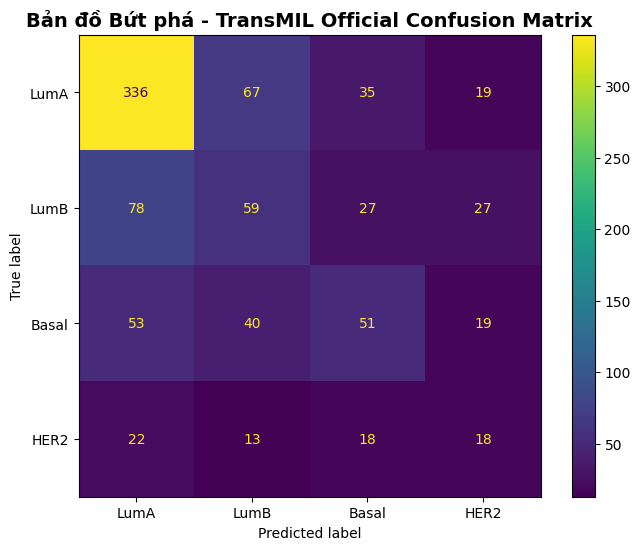

In [6]:
if len(valid_pids) > 0:
    cm = confusion_matrix(best_global_labels, best_global_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LumA', 'LumB', 'Basal', 'HER2'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='viridis', ax=ax, values_format='d') 
    plt.title('Bản đồ Bứt phá - TransMIL Official Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()